In [1]:
import pandas as pd

# header=None tells pandas the first row is data, not column names
df = pd.read_csv("wdbc.data", header=None)

# WDBC layout: ID, targets, then 30 measurements
features = ["radius", "texture", "perimeter", "area", "smoothness",
            "compactness", "concavity", "concave_points", "symmetry", "fractal_dim"]
cols = (["id", "target"]
        + [f"{f}_mean" for f in features]
        + [f"{f}_se" for f in features]
        + [f"{f}_worst" for f in features])
df.columns = cols

df["target"] = df["target"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame   # 'target' column: 0 = malignant, 1 = benign

In [4]:
import pandas as pd
import numpy as np

print(df.head(10))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   
5        12.45         15.70           82.57      477.1          0.12780   
6        18.25         19.98          119.60     1040.0          0.09463   
7        13.71         20.83           90.20      577.9          0.11890   
8        13.00         21.82           87.50      519.8          0.12730   
9        12.46         24.04           83.97      475.9          0.11860   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760         0.30010              0.14710         0.2419   
1           0

In [5]:
print(df.describe)

<bound method NDFrame.describe of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean c

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
print("Missing values")
print(df.isnull().sum())

Missing values
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [8]:
print("duplicate rows", df.duplicated().sum())

duplicate rows 0


In [9]:
print ("Column names")
print(df.columns.tolist)

Column names
<bound method IndexOpsMixin.tolist of Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')>


In [10]:
df["mean area"] = df["mean area"].fillna(df.groupby ("target")["mean area"].transform("median"))

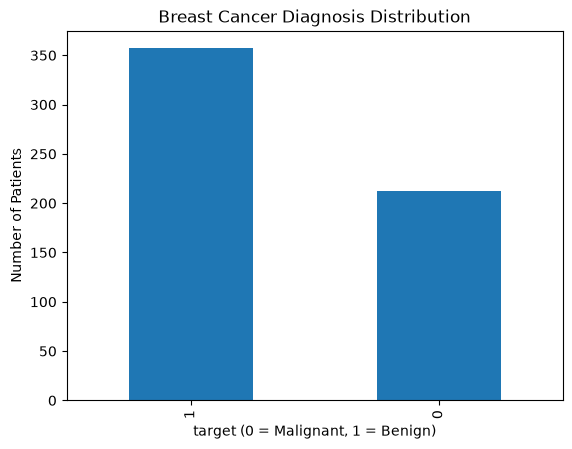

In [11]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title("Breast Cancer Diagnosis Distribution")
plt.xlabel("target (0 = Malignant, 1 = Benign)")
plt.ylabel("Number of Patients")
plt.show()

In [12]:
print(df['target'].value_counts(normalize=True) * 100)

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


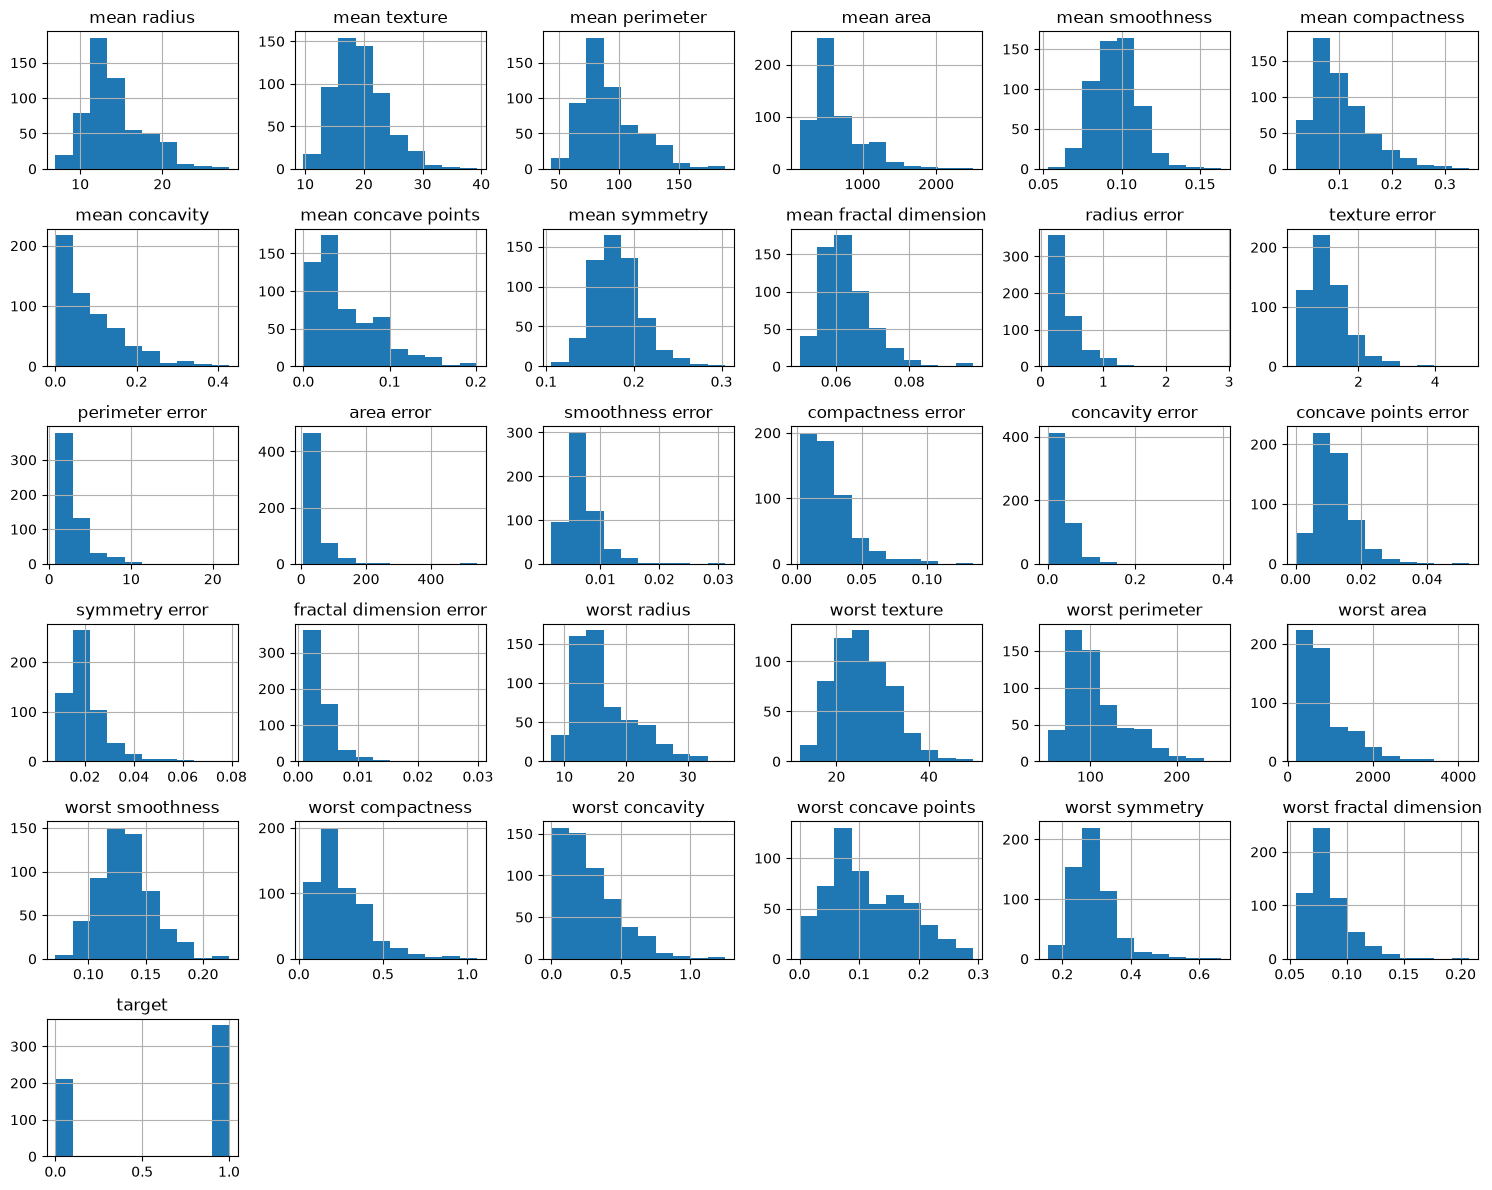

In [13]:
df.hist(figsize=(15, 12))

plt.tight_layout()
plt.show()

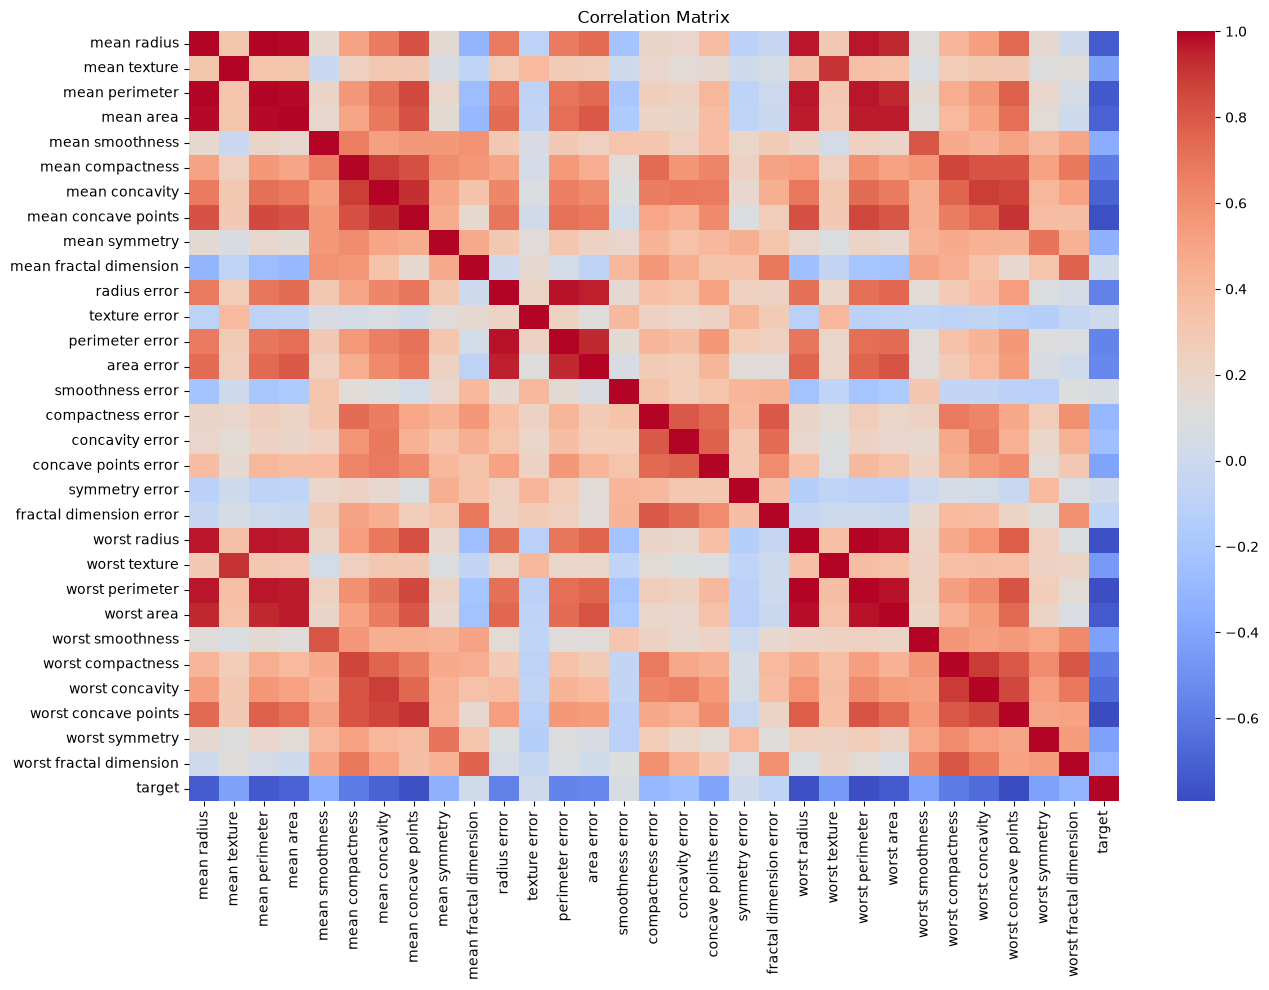

In [14]:
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

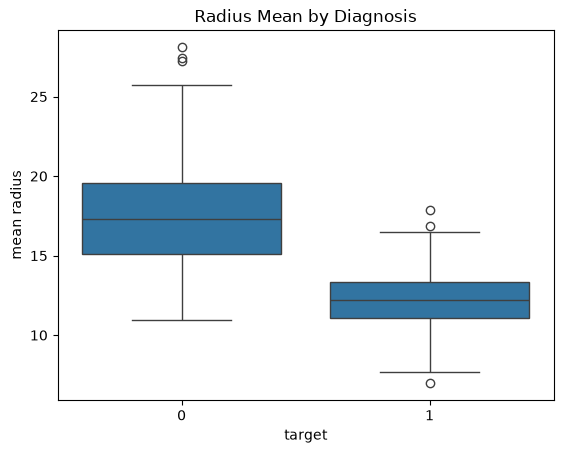

In [15]:
sns.boxplot(
    data=df,
    x='target',
    y='mean radius'
)

plt.title("Radius Mean by Diagnosis")
plt.show()

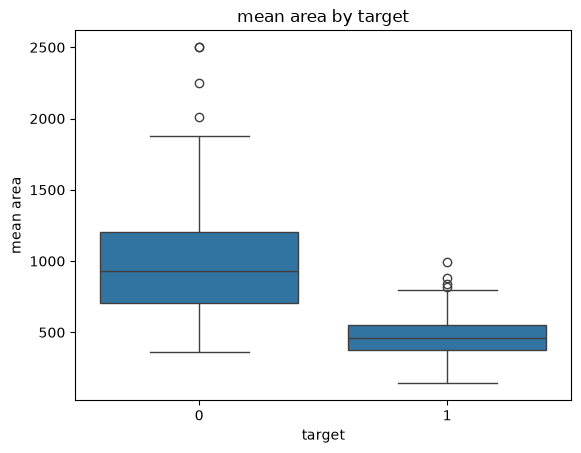

In [17]:
sns.boxplot(
    data=df,
    x='target',
    y='mean area'
)

plt.title("mean area by target")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [22]:
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [27]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred):
    print("\n", name)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

evaluate_model(
    "SVM",
    y_test,
    y_pred_svm
)

evaluate_model(
    "KNN",
    y_test,
    y_pred_knn
)


 Logistic Regression
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112

 Random Forest
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104

 SVM
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112

 KNN
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


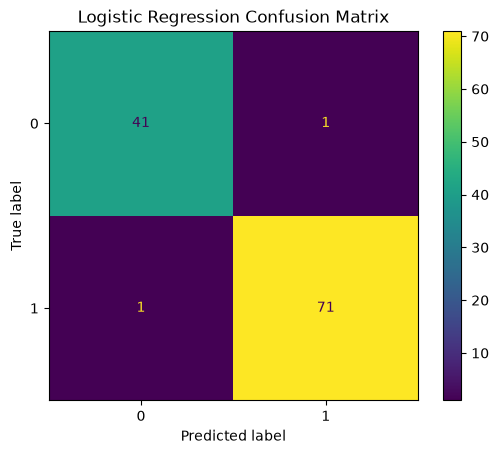

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

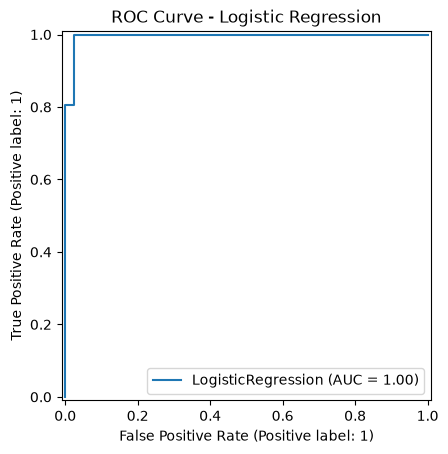

In [31]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [32]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(
    y_test,
    lr.predict_proba(X_test_scaled)[:, 1]
)

auc_rf = roc_auc_score(
    y_test,
    rf.predict_proba(X_test)[:, 1]
)

print("Logistic Regression AUC:", auc_lr)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.9953703703703703
Random Forest AUC: 0.9930555555555556


In [51]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                 Feature  Importance
22       worst perimeter    0.133100
23            worst area    0.128052
27  worst concave points    0.108107
7    mean concave points    0.094414
20          worst radius    0.090639
0            mean radius    0.058662
2         mean perimeter    0.055242
3              mean area    0.049938
6         mean concavity    0.046207
26       worst concavity    0.035357
13            area error    0.034368
5       mean compactness    0.018094
21         worst texture    0.017869
25     worst compactness    0.014481
1           mean texture    0.014317


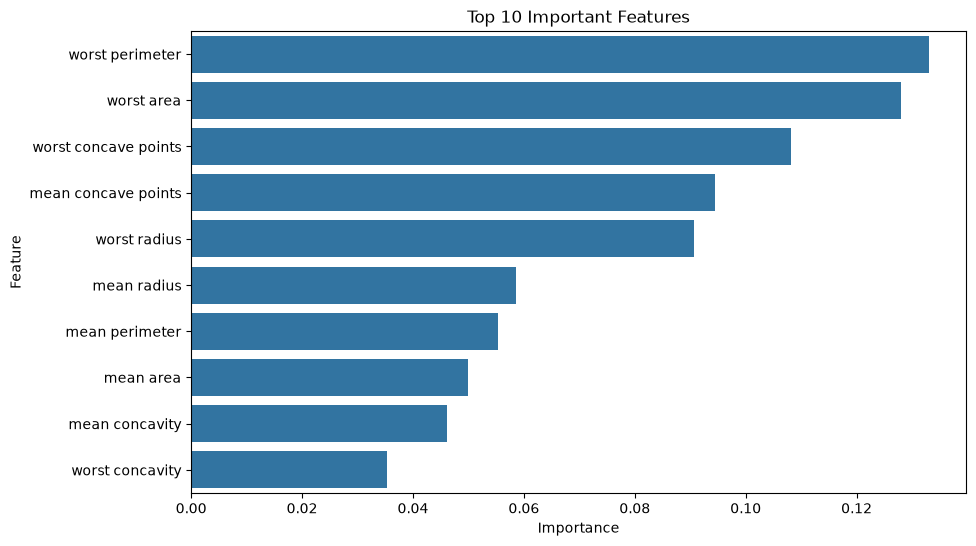

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.92105263 0.93859649 0.98245614 0.97368421 0.97345133]
Mean accuracy: 0.9578481602235678


In [36]:
cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='recall'
)

array([0.92957746, 0.98591549, 0.98611111, 0.98611111, 0.97183099])

In [37]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

Best parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [48]:
y_pred = best_model.predict(X_test)


print(best_model.score(X_test, y_test))

0.956140350877193


In [53]:
git init

SyntaxError: invalid syntax (2830201818.py, line 1)